# PCA visualization of Big Five response vectors

Projects 50-dim item response vectors (humans + AI models) to 2D via PCA
to visualize whether model responses cluster with humans or form distinct clusters.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Config

In [13]:
AI_FILE = "big5_merged_80000.csv"
HUMAN_HF_DATASET = "Cecilia-lll/IPIP-BFFM-openpsy"
HUMAN_HF_FILE = "data-cleaned.csv"

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Number of points sampled per group (humans, and per AI model) for the scatter.
# 2000 x 9 groups = ~18k points total. Balanced so humans don't swamp the plot.
# Increase to 5000 for a denser figure; decrease to 1000 for faster iteration.
N_PER_GROUP = 2000
RANDOM_STATE = 42

TRAIT_PREFIXES = ["EXT", "EST", "AGR", "CSN", "OPN"]
ITEM_COLS = [f"{p}{i}" for p in TRAIT_PREFIXES for i in range(1, 11)]

# Map each model to a family. "Human" is its own family.
MODEL_FAMILY = {
    "claude-haiku-4.5":              "Claude",
    "claude-sonnet-4.6":             "Claude",
    "gpt-5.4":                       "OpenAI",
    "gpt-5.4-mini":                  "OpenAI",
    "gpt-5.4-nano":                  "OpenAI",
    "gemini-3-flash-preview":        "Gemini",
    "gemini-3.1-flash-lite-preview": "Gemini",
    "deepseek-v3.2":                 "DeepSeek",
}

# Fixed 9-class palette with strong separation and balanced aesthetics.
# Order is: Human + sorted model names.
CLASS_PALETTE_9 = [
    "#4D4D4D",  # Human: neutral charcoal
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
    "#EDC948",  # gold
    "#B07AA1",  # purple
    "#9C755F",  # brown
]

# Plots
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.titlecolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        'black',
    'lines.color':       'black',
    # 'grid.alpha':        0.3,
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'legend.labelcolor': 'black',
})

## Load data

In [3]:
ai_raw = pd.read_csv(AI_FILE)
print("AI raw shape:", ai_raw.shape)
print("Models:", sorted(ai_raw["model"].unique()))

AI raw shape: (80000, 52)
Models: ['claude-haiku-4.5', 'claude-sonnet-4.6', 'deepseek-v3.2', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.4-nano']


In [4]:
from datasets import load_dataset
human_raw = load_dataset(HUMAN_HF_DATASET, data_files=HUMAN_HF_FILE, split="train").to_pandas()
print("Human raw shape:", human_raw.shape)

/home/wzhan969/miniconda3/envs/humanLLM/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Human raw shape: (500703, 136)


## Clean: keep only the 50 item columns; drop NaNs; drop flagged humans.

In [5]:
def clean_items(df, has_exclude=False):
    out = df.copy()
    if has_exclude and "exclude_any" in out.columns:
        out = out.loc[~out["exclude_any"].fillna(False)].copy()
    for c in ITEM_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna(subset=ITEM_COLS).reset_index(drop=True)
    return out

human = clean_items(human_raw, has_exclude=True)
ai    = clean_items(ai_raw,    has_exclude=False)
print("Human clean:", human.shape, "AI clean:", ai.shape)

Human clean: (500703, 136) AI clean: (80000, 52)


## Balanced sampling: N_PER_GROUP per group

In [6]:
rng = np.random.default_rng(RANDOM_STATE)

def sample_rows(df, n):
    if len(df) <= n:
        return df.copy()
    idx = rng.choice(len(df), size=n, replace=False)
    return df.iloc[idx].copy()

parts = []
human_s = sample_rows(human[ITEM_COLS], N_PER_GROUP)
human_s["group"]  = "Human"
human_s["family"] = "Human"
parts.append(human_s)

for m in sorted(ai["model"].unique()):
    sub = ai.loc[ai["model"] == m, ITEM_COLS]
    sub_s = sample_rows(sub, N_PER_GROUP)
    sub_s["group"]  = m
    sub_s["family"] = MODEL_FAMILY.get(m, "Other")
    parts.append(sub_s)

data = pd.concat(parts, ignore_index=True)
print("Sampled total:", data.shape)
print(data["group"].value_counts())

Sampled total: (18000, 52)
group
Human                            2000
claude-haiku-4.5                 2000
claude-sonnet-4.6                2000
deepseek-v3.2                    2000
gemini-3-flash-preview           2000
gemini-3.1-flash-lite-preview    2000
gpt-5.4                          2000
gpt-5.4-mini                     2000
gpt-5.4-nano                     2000
Name: count, dtype: int64


## PCA (standardize first so all 50 items contribute comparably)

In [14]:
X = data[ITEM_COLS].to_numpy(dtype=float)
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(Xs)
data["PC1"] = Z[:, 0]
data["PC2"] = Z[:, 1]

evr = pca.explained_variance_ratio_
print(f"Explained variance: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}, total={evr.sum():.3f}")

Explained variance: PC1=0.264, PC2=0.142, total=0.406


## Group means in the original 50-dim space, then projected onto PCA plane

PCA is linear, so the projection of a 50-dim group mean equals the mean of that group's PC scores (up to the constant global centering done by PCA). We compute it from the 50-dim vectors explicitly so we can also report pairwise distances between group means in the original 50-dim space — that is what makes "AI mean ≈ Human mean" concrete, while the scatter cloud shows the per-sample distributions are very different.

In [ ]:
CLASS_ORDER = ["Human"] + sorted(MODEL_FAMILY.keys())

group_means_50d = (
    data.groupby("group")[ITEM_COLS].mean().reindex(CLASS_ORDER).dropna(how="all")
)

means_centered = group_means_50d.to_numpy() - X.mean(axis=0, keepdims=True)
means_scaled   = means_centered / StandardScaler().fit(X).scale_
means_pc       = pca.transform(means_scaled)
group_means_pc = pd.DataFrame(
    means_pc, index=group_means_50d.index, columns=["PC1", "PC2"]
)

human_mean_50d = group_means_50d.loc["Human"].to_numpy()
print("L2 distance (50-dim) from each group mean to Human mean:")
for g, vec in group_means_50d.iterrows():
    d = float(np.linalg.norm(vec.to_numpy() - human_mean_50d))
    print(f"  {g:35s} {d:.4f}")

## Build per-model colors: one spectrum per family

## Plot

In [15]:
CLASS_ORDER = ["Human"] + sorted(MODEL_FAMILY.keys())
if len(CLASS_ORDER) > len(CLASS_PALETTE_9):
    raise ValueError(
        f"Need {len(CLASS_ORDER)} colors, but only {len(CLASS_PALETTE_9)} are defined in CLASS_PALETTE_9."
    )

COLORS = {g: c for g, c in zip(CLASS_ORDER, CLASS_PALETTE_9)}
for g in CLASS_ORDER:
    print(g, COLORS[g])

Human #4D4D4D
claude-haiku-4.5 #4E79A7
claude-sonnet-4.6 #F28E2B
deepseek-v3.2 #E15759
gemini-3-flash-preview #76B7B2
gemini-3.1-flash-lite-preview #59A14F
gpt-5.4 #EDC948
gpt-5.4-mini #B07AA1
gpt-5.4-nano #9C755F


Saved: outputs/pca_responses_2000per_group.png


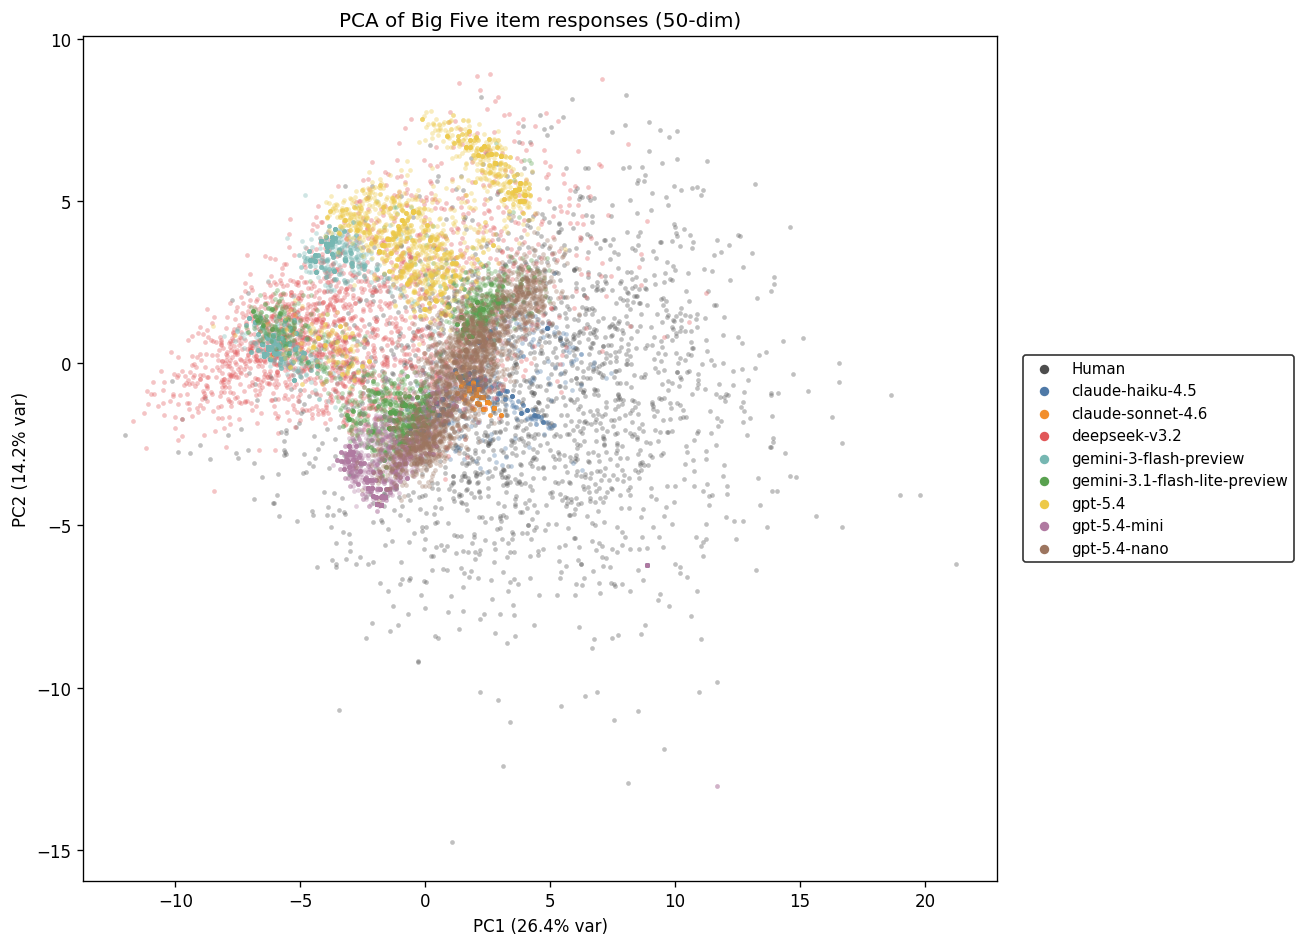

In [16]:
fig, ax = plt.subplots(figsize=(11, 8), dpi=120)

# Draw humans first (background), then AI on top.
draw_order = ["Human"] + [m for m in sorted(MODEL_FAMILY.keys())]
for g in draw_order:
    sub = data.loc[data["group"] == g]
    if sub.empty:
        continue
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=8, alpha=0.35,
        c=[COLORS[g]], label=g,
        linewidths=0, rasterized=True,
    )

# Overlay group mean vectors on top of the cloud.
for g in draw_order:
    if g not in group_means_pc.index:
        continue
    mx, my = group_means_pc.loc[g, "PC1"], group_means_pc.loc[g, "PC2"]
    ax.scatter(
        mx, my,
        marker="*", s=420,
        c=[COLORS[g]], edgecolors="black", linewidths=1.4,
        zorder=10,
    )

# One legend entry that explains the star marker.
ax.scatter(
    [], [], marker="*", s=220, c="white", edgecolors="black",
    linewidths=1.2, label="Group mean (50-dim → PCA)",
)

ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
ax.set_title(f"PCA of Big Five item responses (50-dim)")

leg = ax.legend(
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, fontsize=9, markerscale=2,
)
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

plt.tight_layout()
out_path = OUT_DIR / f"pca_responses_{N_PER_GROUP}per_group.png"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
print("Saved:", out_path)
plt.show()

## Optional: per-family facet (humans + one family at a time)
Makes cluster overlap with humans easier to read when families overlap.

Saved: outputs/pca_responses_facets_2000per_group.png


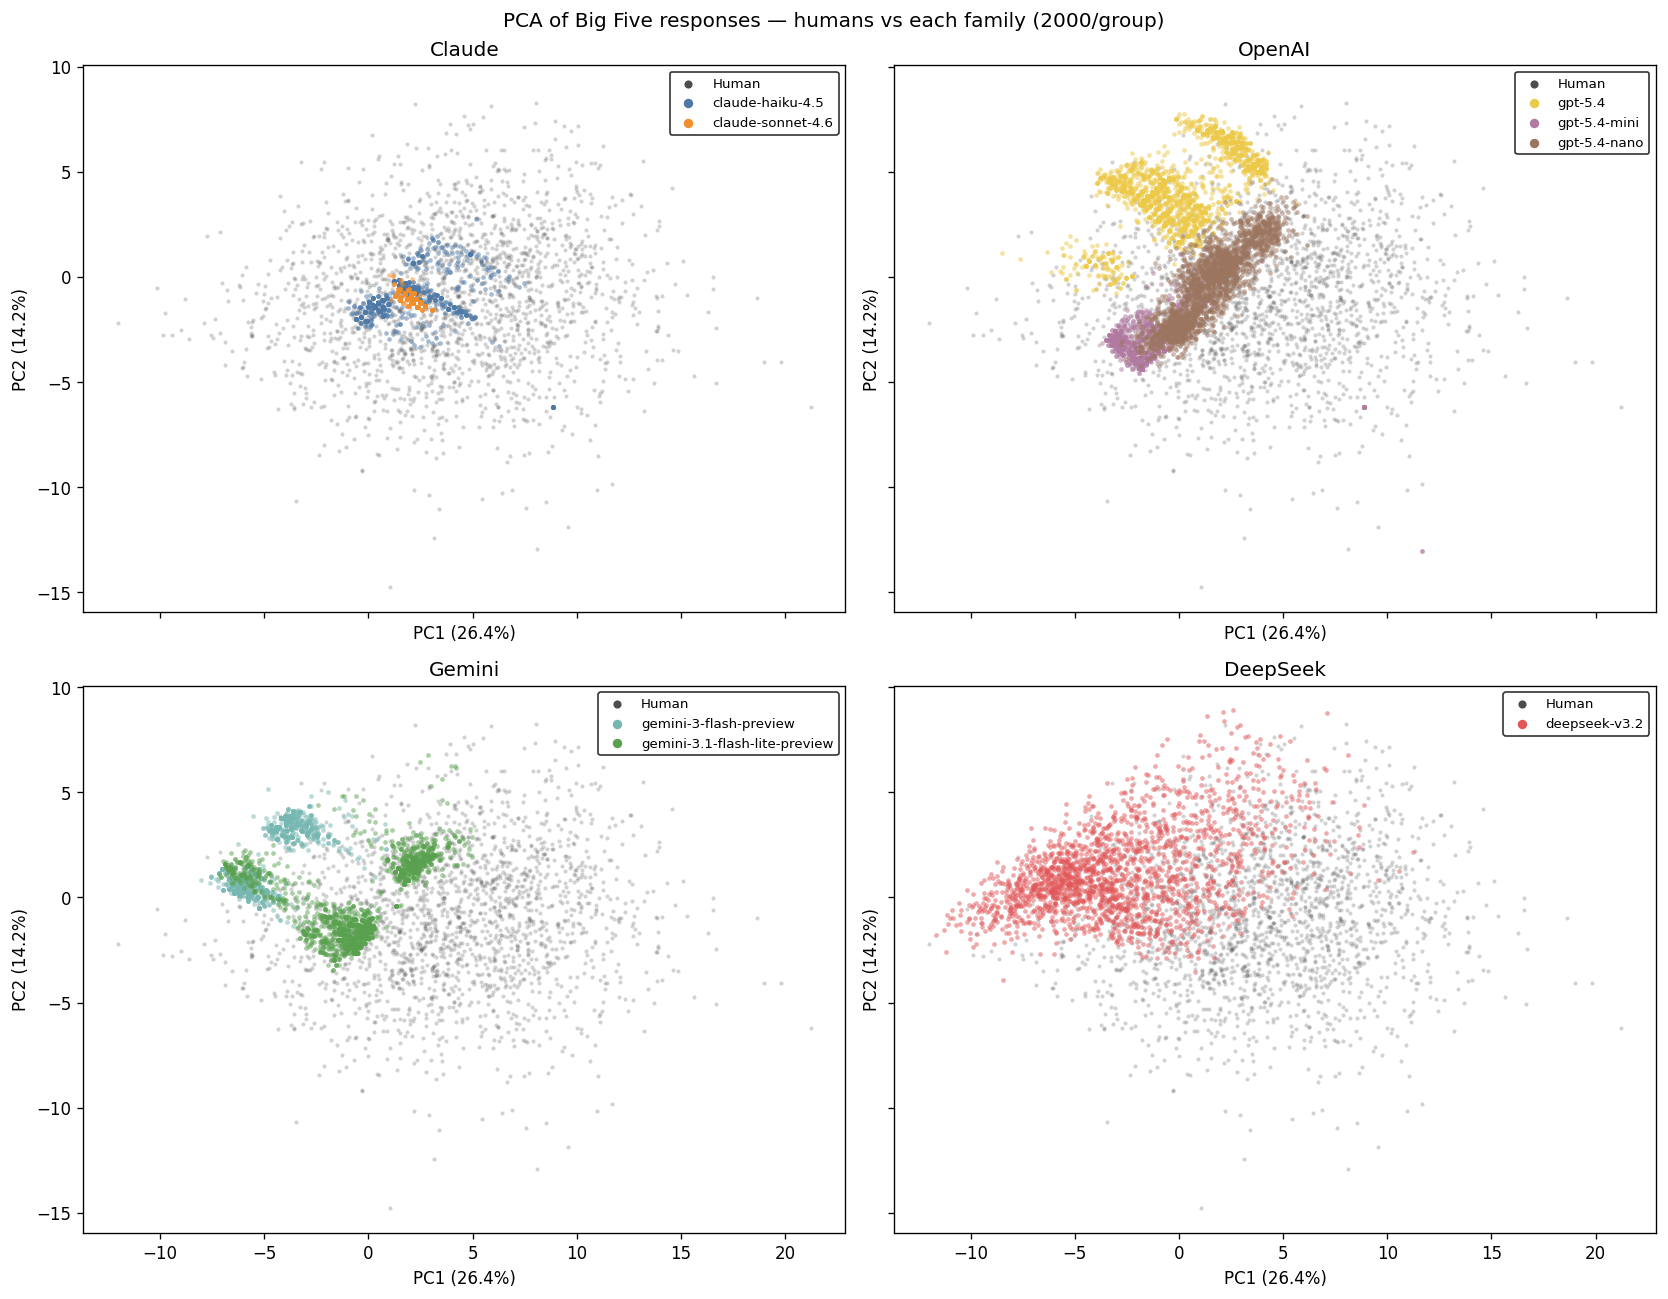

In [17]:
families = ["Claude", "OpenAI", "Gemini", "DeepSeek"]
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=120, sharex=True, sharey=True)

def _plot_mean(ax, g):
    if g not in group_means_pc.index:
        return
    mx, my = group_means_pc.loc[g, "PC1"], group_means_pc.loc[g, "PC2"]
    ax.scatter(mx, my, marker="*", s=320,
               c=[COLORS[g]], edgecolors="black", linewidths=1.2, zorder=10)

for ax, fam in zip(axes.flat, families):
    h = data.loc[data["group"] == "Human"]
    ax.scatter(h["PC1"], h["PC2"], s=6, alpha=0.25, c=[COLORS["Human"]],
               label="Human", linewidths=0, rasterized=True)
    fam_models = [m for m, f in MODEL_FAMILY.items() if f == fam]
    for m in fam_models:
        sub = data.loc[data["group"] == m]
        ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.5, c=[COLORS[m]],
                   label=m, linewidths=0, rasterized=True)

    _plot_mean(ax, "Human")
    for m in fam_models:
        _plot_mean(ax, m)

    ax.set_title(fam)
    ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
    leg = ax.legend(fontsize=8, markerscale=2, loc="best")
    for lh in leg.legend_handles:
        lh.set_alpha(1.0)

plt.suptitle(f"PCA of Big Five responses — humans vs each family ({N_PER_GROUP}/group)")
plt.tight_layout()
out_path2 = OUT_DIR / f"pca_responses_facets_{N_PER_GROUP}per_group.png"
plt.savefig(out_path2, bbox_inches="tight", dpi=150)
print("Saved:", out_path2)
plt.show()

## Save PCA scores for downstream plotting / clustering metrics

In [ ]:
data[["group", "family", "PC1", "PC2"]].to_csv(
    OUT_DIR / f"pca_scores_{N_PER_GROUP}per_group.csv", index=False,
)
print("Saved PCA scores CSV.")

means_out = group_means_pc.copy()
means_out["dist_to_human_50d"] = [
    float(np.linalg.norm(group_means_50d.loc[g].to_numpy() - human_mean_50d))
    for g in means_out.index
]
means_out.to_csv(OUT_DIR / f"pca_group_means_{N_PER_GROUP}per_group.csv")
print("Saved group means CSV.")